In [1]:
import torch
import time
import warnings
import os
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from numba.core.errors import NumbaWarning

from device import setup_device
from datasets.utk_dataset import UTKFaceDataset
from datasets.loading import get_full_loader, get_data_loaders
from datasets.extraction import extract_embeddings
from model.encoder import Encoder
from model.loading import load_model
from loss import *
from train.train_encoder import *
from analysis.visualization import *
from analysis.monitor import (
    CompositeMonitor,
    LoggingMonitor,
    OptimumMonitor,
    EarlyStoppingMonitor,
    SaveModelMonitor,
    TensorboardMonitor,
)
from optim.optimizer import get_optimizer
from optim.scheduler import get_scheduler

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")
warnings.filterwarnings("ignore", category=NumbaWarning)
warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")
warnings.filterwarnings("ignore", message=".*epoch parameter in `scheduler.step.*")

In [3]:
verbose=True

In [4]:
device, data_parallel = setup_device(use_gpu_1_only=False, verbose=verbose)

[03:19:13] [INFO] ✅ CUDA is available: 2 GPU(s) visible


In [5]:
backbone_model = 'resnet50'
pretrained = True
model = Encoder(backbone_name=backbone_model, pretrained=pretrained)
model = data_parallel(model).to(device)

[03:19:13] [INFO] 🚀 Wrapping model in DataParallel over 2 GPUs


In [6]:
test_dir = './outputs/current/initial_test'
best_model_file = os.path.join(test_dir, 'best_model.pth')
key_metric = 'kendall'
mode = 'max'
analysis_dir = os.path.join(test_dir, 'analysis')

In [7]:
writer = SummaryWriter(log_dir=test_dir)
monitor = CompositeMonitor([
    LoggingMonitor(key_metric=key_metric, mode=mode, verbose=True),
    OptimumMonitor(key_metric=key_metric, mode=mode, save_path=best_model_file, verbose=verbose),
    EarlyStoppingMonitor(key_metric=key_metric, patience=10, delta=1e-4, mode=mode, verbose=verbose),
    SaveModelMonitor(save_dir=analysis_dir),
    TensorboardMonitor(writer)
])

In [8]:
learning_rate = 1e-3
data_folder = './data/utkface/UTKFace'
augmentations = 'crop,flip,color,grayscale'
batch_size = 256
train_size = 0.8

# Build data loaders
train_loader, val_loader = get_data_loaders(
    data_folder, augmentations,
    batch_size=batch_size, train_size=train_size
)

# Optimizer and scheduler
optimizer = get_optimizer('adam', model, learning_rate)
scheduler = get_scheduler('steplr', optimizer, step_size=10, gamma=0.1)

In [9]:
train_config = {
    'model': model,
    'num_epochs': 2,
    'monitor': monitor,
    'metrics': [
        "val_loss",
        "embedding_norm",
        "embedding_variance",
        "knn_accuracy",
        "spearman",
        "kendall",
        "grad_norm",
        "lr"
    ]
}

config = {
    'device': device,
    'train_loader': train_loader,
    'val_loader': val_loader,
    'optimizer': optimizer,
    'scheduler': scheduler,
    'temperature': 0.5,
    'train_config': train_config
}

In [10]:
start_time = time.time()
train_encoder(config, verbose=verbose)
end_time = time.time()
print_verbose(f"Training completed in: {end_time - start_time:.2f} seconds", verbose)

[03:19:13] [INFO] Configuration check passed: 7 keys found.
[03:19:13] [INFO] Configuration check passed: 9 keys found.
[03:19:13] [INFO] Training on device: cuda


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.43batch/s]


[03:20:16] [INFO] [Epoch 0] kendall: 0.4861 (max)
[03:20:17] [INFO] ✅ New best kendall: 0.4861 (max)


Extracting Embeddings: 100%|██████████████████████████████| 19/19 [ 6.36batch/s]


[03:21:20] [INFO] [Epoch 1] kendall: 0.5359 (max)
[03:21:20] [INFO] ✅ New best kendall: 0.5359 (max)
[03:21:20] [INFO] Training complete!
[03:21:20] [INFO] Training completed in: 126.78 seconds


In [11]:
model = load_model(model, best_model_file, verbose=verbose)
full_loader = get_full_loader('./data/utkface/UTKFace')

# Disable the projection layer
if hasattr(model, 'projector'):
    model.projector = nn.Identity()
        
embeddings, labels = extract_embeddings(model, full_loader, device=device, verbose=verbose)
print_verbose(f"Shape of embeddings: {tuple(embeddings.shape)}", verbose)
print_verbose(f"Memory usage of embeddings: {embeddings.nbytes / (1024 ** 2):.2f} MB", verbose) 

[03:21:20] [INFO] Loaded model from ./outputs/current/initial_test/best_model.pth, epoch 1, best loss: 4.9808


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.39batch/s]

[03:21:39] [INFO] Shape of embeddings: (23708, 128)
[03:21:39] [INFO] Memory usage of embeddings: 11.58 MB


In [12]:
checkpoint_dir = os.path.join(test_dir, 'analysis')
checkpoint_files = sorted(
    [f for f in os.listdir(checkpoint_dir) if f.startswith("epoch_") and f.endswith(".pt")]
)

embeddings_list = []
labels_list = []

full_loader = get_full_loader('./data/utkface/UTKFace')

for ckpt_file in checkpoint_files:
    model_path = os.path.join(checkpoint_dir, ckpt_file)
    
    # Load model from checkpoint
    model = load_model(model, model_path, verbose=verbose)
    model.to(device)
    model.eval()

    # Disable the projection layer if present
    if hasattr(model, 'projector'):
        model.projector = nn.Identity()

    # Extract embeddings and labels        
    embeddings, labels = extract_embeddings(model, full_loader, device=device, verbose=verbose)

    # Append
    embeddings_list.append(embeddings)
    labels_list.append(labels)

[03:21:39] [INFO] Loaded model from ./outputs/current/initial_test/analysis/epoch_000.pt, epoch 0, best loss: 5.0799


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.61batch/s]


[03:21:58] [INFO] Loaded model from ./outputs/current/initial_test/analysis/epoch_001.pt, epoch 1, best loss: 4.9781


Extracting Embeddings: 100%|████████████████████████████| 371/371 [19.45batch/s]


[03:22:17] [INFO] [visualize] Running: umap
[03:22:39] [INFO] [plot_umap] embeddings: (23708, 128), labels: (23708,)


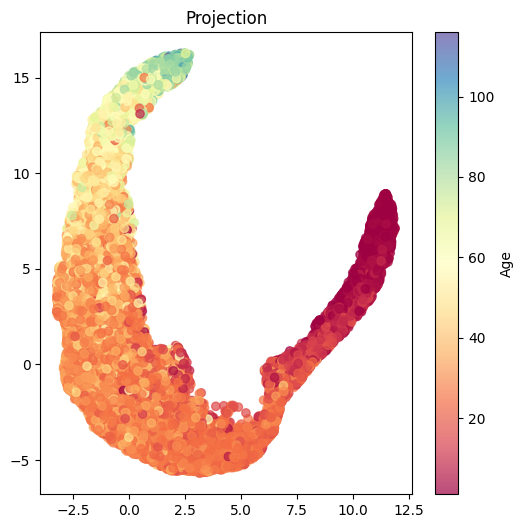

[03:22:39] [INFO] [visualize] Running: similarity_matrix
[03:22:40] [INFO] [plot_similarity_matrix] embeddings: torch.Size([1500, 128]), labels: torch.Size([1500])


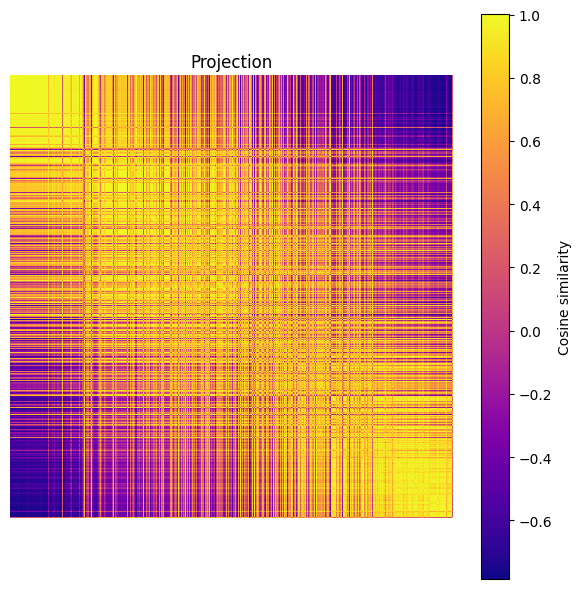

[03:22:40] [INFO] [visualize] Running: umap_all
[03:22:48] [INFO] [plot_umap_all_epochs_grid] Epoch 0: (23708, 128), (23708,)
[03:22:56] [INFO] [plot_umap_all_epochs_grid] Epoch 1: (23708, 128), (23708,)


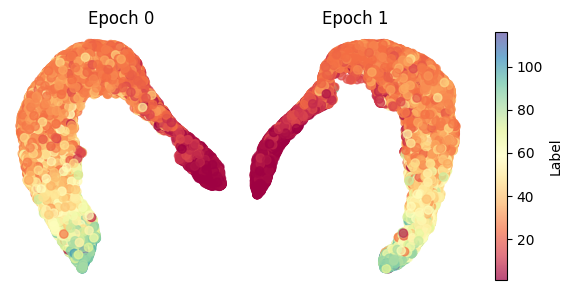

[03:22:56] [INFO] Visualization computed in: 38.74 seconds


In [13]:
selected = ['umap', 'similarity_matrix', 'umap_all']

args = {
    'embeddings': embeddings,
    'labels': labels,
    'figsize': (6, 6),
    'figssize': (3, 3),
    'n': 1500,
    'title': 'Projection',
    'embeddings_list': embeddings_list,
    'labels_list': labels_list
}

start_time = time.time()
visualize(selected, args, verbose=verbose)
end_time = time.time()

print_verbose(f"Visualization computed in: {end_time - start_time:.2f} seconds", verbose)